# **PyIU Python Crash Course (Solutions)**
## Last updated March 24, 2026
### Authors: Brandon Radzom, Sarah Popp, Amelia Binau, Samantha Goldberg, Robert Howard, Daniel Ornelas, Jessica Ranshaw, Daniel Gallego, Tyler Hinrichs, Katherine Barber, Lexi Gault, Kristin Baker

<br>

## **Science Topic:** The Hertzsprung-Russell Diagram
#### Further readings available in the open-source *Astronomy 2e* textbook (ISBN-13: 978-1-951693-50-3):
*   Chapter 18.4: The H-R Diagram https://openstax.org/books/astronomy-2e/pages/18-4-the-h-r-diagram
*   Chapter 17.1: The Brightness of Stars https://openstax.org/books/astronomy-2e/pages/17-1-the-brightness-of-stars

In 1911, Danish astronomer Ejnar Hertzsprung discovered that the **temperature and luminosity (brightness) of stars** are related, which was independently discovered by the American astronomer Henry Norris Russell in 1913, who plotted these quantities against each other for the first time. Named in honor of these two astronomers, the **Hertzsprung-Russell (H-R) diagram** has since become a fundamental tool in astronomy. Further research in the field has shown that, not only are temperature and luminosity related, but they are also indicative of a **star's age and evolutionary state**. Specifically, the clustering of stars in certain regions of the diagram tells us how long they spend in each phase of their life and the physics behind that evolutionary state.

<center><img src="https://raw.githubusercontent.com/pyiu-workshops/pyiu/refs/heads/main/crash-course/hr-diagram/imgs/hr_diagram.jpg" width="500" alt="Hertzsprung-Russell diagram showing where main-sequence stars, giants, supergiants, and white dwarfs lie"/></center>

As depicted in the H-R diagram above, most stars lie along a narrow sequence running from the upper left (corresponding to hot, luminous stars) to the lower right (corresponding to cooler, less luminous stars). This region is called the main sequence, which is where most stars will spend most of their lives, including our Sun. The clear correlation between temperature and luminosity along the main sequence demonstrates that hotter stars are more luminous than cooler stars.

By comparing the H-R diagram with models of stellar evolution, astronomers have learned that stars generally undergo similar evolution tracks, just over vastly different timescales. This progression is as follows: 1) a brief **pre-main sequence** phase where a protostar forms and accretes mass, 2) a long **main sequence** phase where the star slowly burns (fuses) its hydrogen into helium in its core, 3) a short **giant** phase where the star stops core hydrogen burning and expands its radius significantly, and 4) a stellar **death** phase, where its outer layers are lost, either as a planetary nebula or a violent supernova, resulting in a hot, dense, relatively dim object. The exact details behind these evolutionary phases depend largely on the star's mass. Cooler stars like our Sun are lower in mass, so they tend to burn hydrogen more slowly and live longer, and will become red giants following the main sequence phase, and white dwarfs following the red giant phase. Hotter, more massive stars have shorter lifespans and can become supergiants, ultimately resulting in either a neutron star or a black hole. See Chapter 18.4 of *Astronomy 2e* for more on the H-R diagram and stellar evolution.

### Magnitudes and Colors
In reality, astronomers cannot directly measure the luminosity, or intrinsic brightness, of a star. Instead, astronomers measure a star's apparent brightness, often reported in historic units called magnitudes. An important rule when dealing with magnitudes is that they are logarithmic, not linear, and that **smaller magnitudes correspond to brighter objects** while **larger magnitudes correspond to dimmer objects**. Then, astronomers combine the star's **apparent magnitude** with measurements of its distance to calculate its **absolute magnitude**, or intrinsic brightness. This is done using the famous distance modulus equation, written as

$$m-M = 5 \log(d/10)$$

where $m$ corresponds to apparent magnitude, $M$ is absolute magnitude, and $d$ is distance measured in parsecs (pc). A parsec is a common unit of distance in astronomy, equivalent to 3.26 light-years. There are many methods to measure astronomical distances. *Star clusters*, which comprise thousands of stars densely packed together, are a key tool here, as their stars lie at roughly the same distance from Earth. Thus, knowing the distance to one star in a cluster gives us the distance to all of them!

Similarly to luminosity, astronomers are not able to stick a temperature probe on the surface of other stars (let alone our own Sun!), and instead measure their **color** to estimate temperature. In astronomy, color refers to the difference between magnitudes measured in two filters (i.e., the difference in brightness emitted in two different wavelength regions). Most commonly, astronomers measure the apparent magnitudes of stars in the $B$ and $V$ filters, roughly centered on visible blue and green wavelengths, respectively. Therefore, colors are often measured as $B-V$, where **more negative colors indicate a bluer, hotter star**, while **more positive colors indicate a redder, cooler** star.  See Chapter 17.1 of *Astronomy 2e* to read further on magnitudes.

### Python Fundamentals
This notebook is designed to walk you through the fundamental components of Python, and incrementally apply them to construct and analyze your own H-R diagram based on real astronomical data obtained by Indiana University graduate students' use of the WIYN 0.9-meter telescope on Kitt Peak, AZ. You can read more about the telescope here: https://www.wiyn.org/0.9m/.

<center><img src="https://raw.githubusercontent.com/pyiu-workshops/pyiu/refs/heads/main/crash-course/hr-diagram/imgs/ngc_2420.jpg" width="400" alt="The open cluster NGC 2420"></center>

This demo uses selected data from open cluster NGC 2420 (pictured above). NGC 2420 is an old, metal-poor cluster, which means the abundances of elements other than hydrogen and helium are less than those of the Sun. Apparent $V$ magnitudes (corrected for reddening) and $B-V$ colors are available [on our GitHub](https://raw.githubusercontent.com/pyiu-workshops/pyiu/refs/heads/main/crash-course/hr-diagram/input-data/hr_ngc2420.txt). This file does not include every star in the cluster, but it is enough to make a representative H-R diagram.

In this demo, you will be able to practice the following Python skills:
1. Variable definitions and types
2. Lists
3. Loops
4. Plotting
5. Functions (Appendix)
6. Logic (Appendix)

Let's code!

It is generally best practice to `import` any packages you need at the start of your Python script. Packages are collections of code that other programmers have written and published for the rest of the community to use. We can `import` packages into our code to take advantage of all the functionality they add to base Python.

Let's import the `numpy` and `matplotlib` packages. To run a code cell, either press Shift+Enter or click the Play button on the left of the cell.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

## **1. Variables**

Perhaps the most fundamental component of any programming language is a **variable**, which allows us to store information (like the result of a calculation) in memory, and access that information at any given time. In Python, you can define a variable using the equals `=` operator.

Let's start off with a simple example of storing the sum of 2+1 in a variable:

In [2]:
# Define our first variable called "var_sum"
var_sum = 2 + 1

Generally, variable names should be descriptive, but not too long. Remember, *we are storing data to use later*, so you don't want to repeatedly type out something very long, but you still want the variable name to remind you of its contents. Note that there are special rules for acceptable formats of variable names; for example, spaces are not allowed. A full list can be found here: https://www.w3schools.com/python/python_variables_names.asp


In the example above, "var" is short for "variable," and "sum" tells us that this is a sum of some numbers.

We can output the contents of a variable by passing it as an argument into Python's built-in `print()` function, which "calls" its value from memory and prints the result ($2+1=3$). This function also allows us to include text, which we can separate from our variable using commas. Let's `print` our variable with some preceding text, which we can enclose in quotations (" ") and separate using a comma.

In [3]:
print("Contents of var_sum:", var_sum)

Contents of var_sum: 3


We can perform other operations in Python besides addition. Let's manipulate our variable with subtraction (`-`), multiplication (`*`), division (`/`), and exponentiation (`**`), and output the result using `print` statements as we go.

We will also make use of comments, which are denoted in Python via hash symbols `#` and show up a different color than our code. Any code or text that follows a `#` will not be executed when code is run, allowing you to easily document or add notes on what specific lines of code are doing.

In [4]:
# Subtract 1 from var_sum
var_subtract = var_sum - 1
# Output new result (should be 3-1=2)
print("Subtraction result:", var_subtract)

# Multiply new result by 4
var_mult = var_subtract * 4
# Output new result (should be 2*4=8)
print("Multiplication result:", var_mult)

# Divide new result by 2
var_div = var_mult / 2
# Output new result (should be 8/2=4)
print("Division result:", var_div)

# Square new result
var_square = var_div ** 2
# Output new result (should be 4**2=16)
print("Exponent result:", var_square)

Subtraction result: 2
Multiplication result: 8
Division result: 4.0
Exponent result: 16.0


You may have noticed that the text you enclose in quotations are highlighted in red or some other color. This is Python's interpreter telling you that it recognizes the **type** of that variable to be a `string`. Other built-in variables types include `int` and `float` (for numbers), and `boolean` variables (either `True` or `False`), which are highlighted in a different color.

Here's a short summary of these principal variable types:

- `int`: Whole numbers (integers)
- `float`: Decimal or "floating-point" numbers
- `string`: Text encompassed by quotation marks, either single (`'string1'`) or double (`"string2"`)
- `boolean`: True or False

There are many other variable types in Python. Lists, which we will cover next, represent another fundamental variable type that is built into the language.

### Application to the H-R Diagram

Now that we know how variables work, we can begin to tackle the H-R diagram. Specifically, we can take a look at our data file and save the $B-V$ color and $V$ magnitude of the first star in file, as well as the distance to the star cluster.

We'll run through this application part together in the live demo, but we encourage you to work in small groups to complete the remaining "Application to the H-R Diagram" sections.

In [5]:
# Select a star from the real catalog; using the first row is easiest
# Manually save its B-V color and apparent V magnitude to variables
bv_color = 0.349 # In units of magnitudes
vmag_app = 14.034 # In units of magnitudes

# Save the cluster's distance to a variable
d_pc = 2390 # In units of parsecs (pc)

Now, we can calculate the absolute $V$ magnitude of this star using the distance modulus equation defined above, and print out its $B-V$ color.

In [6]:
# Use the distance modulus equation to compute the star's absolute V magnitude
vmag_abs = vmag_app - 5 * np.log10(d_pc / 10)

print("Star #1's absolute V magnitude is:", vmag_abs)

# Print the star's B-V color
print("Star #1's B-V color is:", bv_color)

Star #1's absolute V magnitude is: 2.1420104952593135
Star #1's B-V color is: 0.349


## **2. Lists**


A **list** is another fundamental way to store information in Python. As the name suggests, they are useful for organizing many individual pieces of information into one place for later reference.

Lists can be defined just like any other variable with the single equal sign operator `=` . To fill the list with **elements** at its definition call, we can use square brackets `[ ]` and commas `,` between each element. Let's make a list now.

In [7]:
# Defining a list variable
list1 = [5, 8, "banana", -22, True, 0.1, "hello", 8.25]

Notice that the list we just defined has more than one variable type within. In fact, it has strings, ints, and floats all together! Lists allow us to store as many variables as we want, even other lists!

Of course, the real usefulness of lists is the user's ability to **index** them. This means that we can access any element in the list whenever we want and wherever it is in the list, without altering the list itself.

To access an element from a list, we can call the name of the list variable followed by square brackets `[ ]` containing that element's **index number**.

In [8]:
# Get an item from the list
item1 = list1[2]
print(item1)

banana


Note that while we asked for element index 2 in the example above, it gave us the 3rd item in the list. This is normal: Python starts indexing elements with the number 0, for historical reasons. *Keep in mind, this implies that the last element in a list always has an index equal to the length of the list minus one!*

We can also get multiple values at once from a list by **slicing** the list using the colon symbol `:` and two index values. Note that the ending index is not included in the slice, while the starting index *is*.

In [9]:
# Get a slice of a list
print(list1[3:6])

[-22, True, 0.1]


The most important operation to learn here is how to add an element to an already-existing list. Elements can be added using the `.append()` method, which is written immediately following the variable name of a given list.

In [10]:
# Make a new list
list2 = [1, 2, 4, 8]
print(list2)

# Add to the list
list2.append("Sixteen")
print(list2)

[1, 2, 4, 8]
[1, 2, 4, 8, 'Sixteen']


Try appending an element to `list2`: it could be anything (for example, a `boolean`, `int`, `float`, or `string`). Then print the result.

In [11]:
# Add your own element to the list
list2.append(True)

# Print the new list
print(list2)

[1, 2, 4, 8, 'Sixteen', True]


 Elements can be removed from a list using either the `.pop()` or `.remove()` methods, which are also built in to Python. Try to remove the integer element 4 from the list we just defined using both methods to test how they work.

In [12]:
# Try to remove the 4 from the list using .pop()
list2.pop()
print(list2)

list2.pop()
print(list2)

list2.pop()
print(list2)

[1, 2, 4, 8, 'Sixteen']
[1, 2, 4, 8]
[1, 2, 4]


In [13]:
# Make a new list again
list2 = [1, 2, 4, 8, "Sixteen"]
print(list2)

[1, 2, 4, 8, 'Sixteen']


In [14]:
# Now try to remove the 4 from the list using .remove()
list2.remove(4)
print(list2)

[1, 2, 8, 'Sixteen']


If you are ever curious how long your list currently is, you can use the `len()` function to return its current length.

In [15]:
# Return the length of the list
print(len(list2))

4


One of the strengths of using a list in Python is that it can contain variables of any type &mdash; even lists! This means that you can have nested lists of data, which is enormously helpful for saving multiple columns of data from a file. Let's define a list that contains our `list1` and `list2` variables, in addition to some other elements:

In [16]:
# Example of nested list:
list3 = [list1, "apple", 3.14159, list2, "pie"]

print('Length of list3:', len(list3))
print('My nested list3:', list3)

Length of list3: 5
My nested list3: [[5, 8, 'banana', -22, True, 0.1, 'hello', 8.25], 'apple', 3.14159, [1, 2, 8, 'Sixteen'], 'pie']


We can see that our `len()` function returned the number of elements or rows in our nested list, which represent the first layer of data. To access each element or row in this 2-layered nested list, we can therefore use the same indexing notation as before:

In [17]:
print("Each element in list3:")
print(list3[0])
print(list3[1])
print(list3[2])
print(list3[3])
print(list3[4])

Each element in list3:
[5, 8, 'banana', -22, True, 0.1, 'hello', 8.25]
apple
3.14159
[1, 2, 8, 'Sixteen']
pie


But what if we want to access the individual elements in our nested lists within `list3`? For each layer in `list3`, all we need to do is tack on an extra set of brackets `[ ]` in our indexing, like so:

In [18]:
# Nested list indexing on the first nested list
print("Element #1 in list3:", list3[0])
print("Element #1 of this nested list within list3:", list3[0][0])

# Try nested list indexing on the other nested list
print("Element #4 in list3:", list3[3])
print("Element #2 of this nested list within list3:", list3[3][1])

Element #1 in list3: [5, 8, 'banana', -22, True, 0.1, 'hello', 8.25]
Element #1 of this nested list within list3: 5
Element #4 in list3: [1, 2, 8, 'Sixteen']
Element #2 of this nested list within list3: 2


Nested lists and indexing are incredibly powerful for data analysis, as most data formats you will work with have at least two layers (rows and columns).

### Application to the H-R Diagram

Now that we have lists at our disposal, it's going to be much easier to work with an entire dataset. Let's use them now to save ALL of the $B-V$ colors and apparent $V$ magnitudes from the stars in our star cluster to lists.

Begin by reading in the two-column data file and printing out its length and its first few elements, to get a feel for the structure of the file.

In [19]:
# Read in the file using numpy and save the contents to a numpy array, which is like a list

# The data are stored in a text file posted on the PyIU GitHub at this url.
# When working locally on a machine, rather than Colab, you would instead
# input the full file path rather than a url.
url = "https://raw.githubusercontent.com/pyiu-workshops/pyiu/refs/heads/main/crash-course/hr-diagram/input-data/hr_ngc2420.txt"
NGC_2420 = np.loadtxt(url, skiprows=2)

print("Length of NGC 2420 Data File:", len(NGC_2420))
print("NGC 2420 Cluster Data Start:\n", NGC_2420[0:3], "\n")

Length of NGC 2420 Data File: 451
NGC 2420 Cluster Data Start:
 [[ 0.349 14.034]
 [ 0.364 14.761]
 [ 0.35  14.941]] 



Now, try to perform your own slice of the file by printing out the last several data points.

Then, you can add the $B-V$ colors (first column) and apparent $V$ magnitudes (second column) of the first three stars in the file to newly-created lists. Think about the conventions we learned above regarding indexing, and how to "double-index," or access elements inside multi-layered lists. Below is a helpful graphic depicting the structure of the data file (left) and some examples for how you can access either column for the first two stars (right).

<center><img src="https://raw.githubusercontent.com/pyiu-workshops/pyiu/refs/heads/main/crash-course/hr-diagram/imgs/double_indexing.jpg" width="600" alt="Annotated double indexing infographic"></center>

In [20]:
# Save the B-V colors and apparent V magnitudes of the first 3 stars to separate lists
bv_colors = []
bv_colors.append(NGC_2420[0][0]) # Remember, the indexing works as [row][column]
bv_colors.append(NGC_2420[1][0])
bv_colors.append(NGC_2420[2][0])

vmags_app = []
vmags_app.append(NGC_2420[0][1]) # Remember, the indexing works as [row][column]
vmags_app.append(NGC_2420[1][1])
vmags_app.append(NGC_2420[2][1])

print("Colors:", bv_colors)
print("Magnitudes:", vmags_app)

Colors: [np.float64(0.349), np.float64(0.364), np.float64(0.35)]
Magnitudes: [np.float64(14.034), np.float64(14.761), np.float64(14.941)]


As we can see, there are over 400 stars in the NGC 2420 cluster. Appending all the $B-V$ colors and apparent $V$ magnitudes to separate lists would take a long time and would be incredibly inefficient. If only there was a way to automate iterating through lists in Python...

## **3. Loops**

Often when coding in Python, we want to apply the same operation to every item in a list. We could do this one at a time, as we started to demonstrate above, but what if our list has a million numbers in it? We don't want to type out a million lines of code! This is where **loops** come in handy. The most common type of loop in Python is the `for` loop. Here's an example of how it works:

In [21]:
# Print out every item in list1, the sample list we made earlier
for item in list1:
    print(item)

5
8
banana
-22
True
0.1
hello
8.25


`for` loops have several important features:
- They must start with the keyword `for`.
- After `for` comes the name of a temporary variable. Each item in the list you iterate over is temporarily stored in this variable while the operations inside the for loop are applied to it.
- Next is the keyword `in`, followed by the name of the list you want to iterate over, and then a colon `:`.
- The operations you want to apply to each item in the list come next, and they must all be indented with a `tab`. This way, Python recognizes that they're part of the `for` loop.

We can also easly access the index of each item in a list while using a `for` loop by using the `range()` and `len()` functions:

In [22]:
# Print out each item in list1, along with its index
for i in range(len(list1)):
    print(list1[i], "is at index", i)

5 is at index 0
8 is at index 1
banana is at index 2
-22 is at index 3
True is at index 4
0.1 is at index 5
hello is at index 6
8.25 is at index 7


The built-in `range()` function can be used to quickly make a list of many values. This function takes in three numbers (start, end, step size), which it uses to define a `list`, but only the end argument is required (it will assume to start at 0 since indexing starts at 0, and use a step size of 1). As above, this function can be used to iterate over the *indices* of a list, instead of directly iterating over its elements. This is generally a safer and more powerful way to write `for` loops as it allows us to potentially index multiple lists *of the same length* in a single iteration and perform operations between their elements.  

### Application to the H-R Diagram

Let's apply what we've learned about `for` loops! Here, we'll store the $B-V$ colors and apparent $V$ magnitudes of all 451 stars into lists, and then we'll use the apparent $V$ magnitudes we've just stored to compute absolute $V$ magnitudes using the distance modulus equation. We'll use the `range(len())` method of defining a `for` loop so that we can access different lists all at the same time.

In [23]:
# Create empty lists to store colors and magnitudes in
# Note that these first two lists have the same names as the ones we defined in the previous section
# This will overwrite the information we stored there, but that's okay!
bv_colors = []
vmags_app = []
vmags_abs = []

# Save the B-V color and apparent V magnitude of each star in the cluster, then compute each star's absolute V magnitude
# Recall the distance modulus equation:
# apparent_magnitude - absolute_magnitude = 5*np.log10(distance_in_pc/10)

for i in range(len(NGC_2420)):
    bv_colors.append(NGC_2420[i][0]) # First column is B-V color
    vmags_app.append(NGC_2420[i][1]) # Second column is apparent V magnitude

    absolute_vmag = vmags_app[i] - 5 * np.log10(d_pc / 10) # Compute absolute V magnitude for all stars
    vmags_abs.append(absolute_vmag)

## **4. Plotting**

So far, we've used **loops** to manipulate our **lists** of data so we can draw conclusions and better understand the **variables** we're working with. What if we want to represent these data visually? Python and its associated packages are particularly well-suited for plotting appealing, digestable graphs.

The two most important packages necessary for creating plots in Python are ***Matplotlib*** and its submodule ***Pyplot*** (which streamlines many of the capabilities of Matplotlib). Both packages offer a wide variety of options for customizing your graph once you write the proper code. Once you're familiar with the basics of Matplotlib and Pyplot, feel free to peruse these packages' websites (often referred to as the "documentation"): [Matplotlib](https://matplotlib.org/); [Pyplot](https://matplotlib.org/stable/api/pyplot_summary.html).

Let's generate a basic scatterplot of cubed numbers. Recall we imported Matplotlib as `matplotlib` and Pyplot as `plt`. We'll use the `scatter` function in Pyplot to graph our numbers on the x-axis and our cubed numbers on the y-axis.

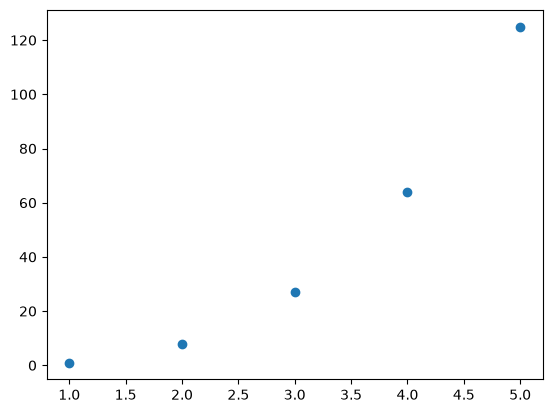

In [24]:
# For simplicity, let's name each list for its corresponding axis.
x = [1, 2, 3, 4, 5]
y = []
for num in x:
    y.append(num**3)

# The "scatter" function is housed under the matplotlib.pyplot module, which we imported as "plt".
# So, we use this function like so:
plt.scatter(x, y)
# The first two arguments of the function are the lists that contain the data to be plotted on the x- and y-axes!

plt.show()
# Whenever we use a function in Matplotlib that generates a plot,
# we use this command to tell the computer to print our resulting graph.

Great! Now we have a simple plot that traces the $y=x^3$ function we would expect from our inputted data! However, this plot is missing some key features: a title and axis labels. These can be generated using Matplotlib functions, too! We can also adjust some aesthetic components, such as the point shape, color, and size, to our liking.

`matplotlib` has many built-in colors and nearly infinite capacity to produce custom colors. Here's a list of the pre-loaded keyword colors:

<center><img src="https://raw.githubusercontent.com/pyiu-workshops/pyiu/refs/heads/main/crash-course/hr-diagram/imgs/matplotlib_named_colors.png" width="700" alt="matplotlib keyword colors"></center>

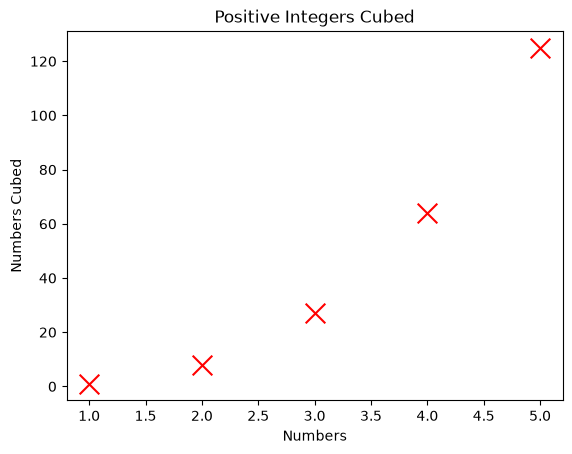

In [25]:
# Let's replot our data using the same "scatter" function.

plt.scatter(x, y, s=200, c="red", marker="x")
# Here, the "s" argument sets the size of the data points,
# the "c" argument sets the color of the points, and the "marker" argument sets the shape of the points.
# See the Matplotlib documentation for more options regarding customization, including color and marker options.

# We add plot title and axis label commands under the plt.scatter() function and before plt.show()

# Axis labels
plt.xlabel("Numbers") # Notice we use strings as our input.
plt.ylabel("Numbers Cubed")

# Plot title
plt.title("Positive Integers Cubed") # Notice we use strings as our input.

plt.show()

Nice. Now, we have a clear title for our plot and axis labels. These are very important features when creating a graph to communicate data.

### Application to the H-R Diagram

Finally, we can combine all we've learned to construct the H-R diagram for our NGC 2420 cluster stars. Let's plot our $B-V$ colors (saved as the variable `bv_colors`) against our absolute $V$ magnitudes (saved as the variable `vmags_abs`):

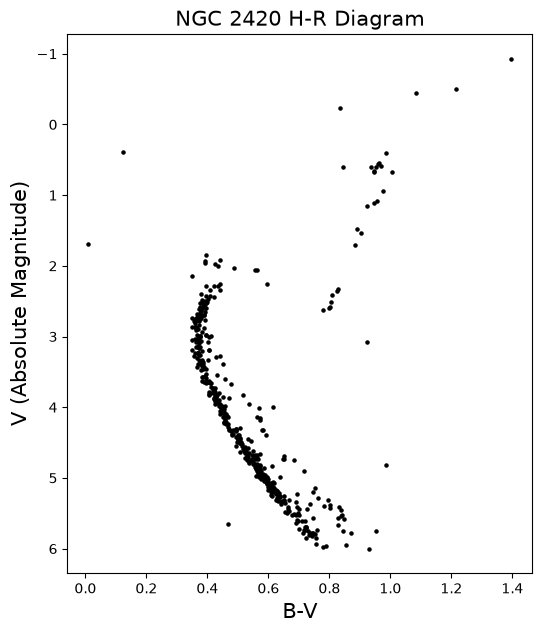

In [26]:
# Create the figure
plt.figure(figsize=(6, 7))
# Plot B-V colors against absolute V magnitudes
plt.scatter(bv_colors, vmags_abs, s=5, c="black")
# Set the plot title and font size
plt.title("NGC 2420 H-R Diagram", size=15)
# Note: we have to invert the y-axis since smaller magnitudes are brighter!
plt.gca().invert_yaxis()

# Set the x- and y-axis labels
plt.xlabel("B-V", size=15) # B-V color
plt.ylabel("V (Absolute Magnitude)", size=15) # Absolute V magnitude

plt.show()

We now have a functioning H-R diagram for our data. If we reference our H-R figure above, we can start to identify some key features. We can use some of `matplotlib`'s tools to make a fancier plot that will help us do this. There are many things to make this plot look as professional as the H-R diagram we saw in the beginning. Let's implement the following changes to our plotting code:

* Change the dpi ("dots per inch," or resolution) of the figure.
* Change the font of the x- and y- axis labels.
* Change the x- and y- axis limits.
* Change the background color.
* Use a color map to color-code the stars by their B-V color.
* Add annotations to the plot.
* Add a figure legend.
* Save the figure to a file.

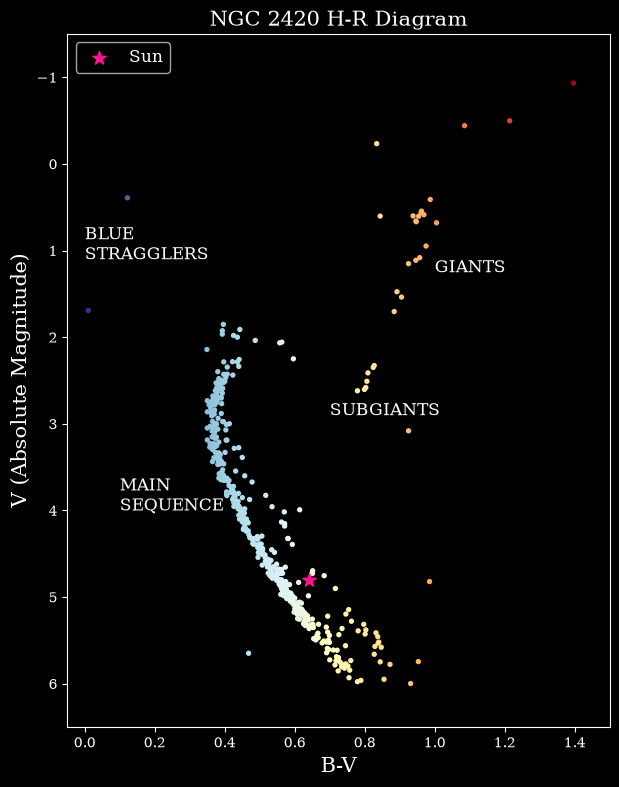

In [27]:
# Set the dpi ("dots per inch," or resolution) of the figure
matplotlib.rcParams["figure.dpi"] = 100
# We can even change the font style!
plt.rcParams["font.family"] = "serif"
# Set the background to be black and the axes and text to be white
plt.style.use("dark_background")

# Create the figure
plt.figure(figsize=(7, 9))

# Set the plot title and font size
plt.title("NGC 2420 H-R Diagram", size=15)
# Plot B-V colors against absolute V magnitudes
plt.scatter(bv_colors, vmags_abs, s=8, c=bv_colors, cmap="RdYlBu_r")
# Plot the approx. B-V color and absolute V magnitude for the Sun (source: https://iopscience.iop.org/article/10.3847/1538-4365/aabfdf)
# Note the "label" argument sets the text label for this data point
plt.scatter(0.64, 4.80, marker="*", s=100, c="deeppink", label="Sun")
# Invert the y-axis, which shows absolute V magnitudes
plt.gca().invert_yaxis()
# Set axis limits
plt.xlim(-0.05, 1.5)
plt.ylim(6.5, -1.5)

# Set axis labels
plt.xlabel("B-V", size=15)
plt.ylabel("V (Absolute Magnitude)", size=15)

# Label key regions of the H-R diagram
plt.annotate("MAIN \nSEQUENCE", xy=(0.1, 4), xycoords="data", size=12)
plt.annotate("GIANTS", xy=(1, 1.25), xycoords="data", size=12)
plt.annotate("SUBGIANTS", xy=(0.7, 2.9), xycoords="data", size=12)
plt.annotate("BLUE \nSTRAGGLERS", xy=(0, 1.1), xycoords="data", size=12)

# Create a figure legend
plt.legend(loc="upper left", fontsize=12)
# Save the figure as a .png file
plt.savefig("hr_diagram.png")
# Show the plot
plt.show()

# Change style settings back to normal
plt.style.use("default")

Et viola! We have a high-quality H-R diagram that closely matches the styling of the original textbook figure above. Plot customization in Python is virtually limitless &mdash; read through the [matplotlib cheat sheets and handouts](https://matplotlib.org/cheatsheets/) to get a grasp on all the most common tools, and explore the official documentation to learn more.

Also note that when working in Colab, using `plt.savefig()` isn't enough to save the figure to your computer &mdash; it's currently only saved temporarily to Google's servers. You will need to explicitly download it: navigate to the **Files** tab on the left-hand side, click on the three vertical dots that show up next to your .png file, and press "Download."

As a final note, besides `plt.scatter()`, another common plotting method within `pyplot` is `plt.plot()`, which can be used to easily generate plots of connected data points (scattered data points can be plotted by setting the `linestyle` argument to "none"). This plotting style is useful when plotting simple or well-parameterized correlations. See some relevant examples on the offical documentation page here: https://matplotlib.org/stable/tutorials/pyplot.html#sphx-glr-tutorials-pyplot-py. Give it a try!

## H-R Diagram Activities

Test your knowledge of these Python fundamentals and the H-R diagram by answering the following questions:

1. Imagine a newly-discovered star in this cluster with a $B-V$ color of 1.00 and an absolute $V$ magnitude of 0.85. Use the H-R diagram to identify the current evolutionary state of this star:  
	a) Main Sequence  
	b) Giant  
	c) Subgiant  
	d) Blue Straggler

2. What fraction of stars in the NGC 2420 cluster are *brighter* than the Sun in the V filter? What about those that are *bluer*? Hint: Read the appendix!

3. Which star in NGC 2420 has the hottest temperature? Report the index (row number) of the star.

4. Imagine that we observe a different cluster with a similar number of stars in it and plot its H-R diagram, finding that there are *no* stars brighter than an absolute $V$ magnitude of 4. Is this cluster younger or older than NGC 2420? Why?

Thanks for participating in our Python Crash Course! For more demos and Python resources, visit [our GitHub](https://github.com/pyiu-workshops/pyiu) or email us at pyiu.bloomington@gmail.com.

# Appendix

You may wonder: what if I wanted to repeat this analysis for different star clusters, each with different lists of data? Would I have to repeat and re-write all this code, including writing out the full distance modulus equation each time?

You could copy-paste everything if you like, but this is very inefficient and would likely lead to some confusion or typos down the road. Luckily, Python allows us to define our own **functions** that can be called to perform repeated tasks. Since we define a function only once, we can repeat our analysis without copy-pasting the same operations over and over again.

## **5. Functions**
Often when programming, we need to perform the same task over and over again, but with different inputs each time. To make this easier and faster, we can define a function. We've already worked with a few built-in functions, like `print()` and `len()`, but we can also define our own using the built-in `def` and `return` keywords:

In [28]:
# Define a function that cubes a number
def cube(n):
    return n**3

# Define a list of sample numbers to cube
nums = list(range(1, 6))

cubed_nums = []
for i in range(len(nums)):
    result = cube(nums[i])  # Call the cube() function with each number in "nums" as an input
    cubed_nums.append(result)

print(nums)
print(cubed_nums)

[1, 2, 3, 4, 5]
[1, 8, 27, 64, 125]


### Application to the H-R Diagram

Let's apply what we've learned about functions to the H-R Diagram by writing a function to calculate absolute magnitudes:

In [29]:
# Write a function based on the distance modulus equation that computes absolute V magnitude
# from apparent V magnitude and distance
def get_abs_mag(app_mag, distance):
    abs_mag = app_mag - 5 * np.log10(distance / 10)
    return abs_mag

# Loop through our list of apparent V magnitudes and use this function to compute the
# absolute V magnitude of every star
vmags_abs_2 = []
for i in range(len(vmags_app)):
    vmags_abs_2.append(get_abs_mag(vmags_app[i], d_pc)) # Call distance modulus function on each star

Now, if we wanted to make an H-R diagram using a different cluster, it would be easy to plug in the new distance and apparent magnitudes to calculate absolute magnitudes for that cluster. Are there other functions you could write to make this easier?

## **6. Logic**

But what does one do if they want to identify outliers in their data, or if they'd like to categorize data based on some specific criteria? This is where the idea of logic, and the `boolean` variable type we introduced earlier, come into play.

Similar to `for` loops, using logic requires specific keywords and syntax to be used. Important features include:
- The `if` keyword, followed by a logical statement (usually some condition you want to test)
- Logical operators that immediately follow `if`, including the `==` operator which tests if two quantities are equal, as well as `<`, `>`, `<=`, and `>=` which test various inequalities between two quantities (less than, greater than, less than or equal to, greater than or equal to, respectively)
- The `else` keyword, which follows the `if` statement and automatically encapsulates all other cases
- A colon `:` at the end of each logical/conditional statement
- The operations you want to carry out if a certain condition is met. These lines of code will be automatically indented by Python to indicate they are within the conditional statement

Let's say, for example, that we had a list of numbers and we wanted to identify and flag negative values, while saving only positive values to a new list. Let's try it:

In [30]:
# Define a list of sample numbers to work with
list4 = [-5, -3, -0.1, 0, 1, 4]
list4_positive = [] # Positive numbers in list4

# Loop through the list
for i in range(len(list4)):
    if list4[i] < 0: # Check if the element is negative
        print(list4[i], "is a negative number")
    else: # If it's not negative, we say that it's positive
        print(list4[i], "is a positive number")
        list4_positive.append(list4[i])

print("list4:", list4)
print("Positive numbers in list4:", list4_positive)

-5 is a negative number
-3 is a negative number
-0.1 is a negative number
0 is a positive number
1 is a positive number
4 is a positive number
list4: [-5, -3, -0.1, 0, 1, 4]
Positive numbers in list4: [0, 1, 4]


Something's a bit off here: 0 is not a positive number, but it was kept in our list regardless since it was not negative. For intermediate cases like this, we can make use of an additional keyword: `elif`, which has the same function as `if` but means "else if". So we can re-write our algorithm as follows:
1) Check if (`if`) a number of the list is negative, then ignore it.
2) Else if (`elif`) the number isn't negative, but ALSO isn't positive (so it is 0), we still want to ignore it.
3) Else (`else`), the number must be positive, so we add it to our positive list.

In [31]:
# Define a list of sample numbers to work with
list4 = [-5, -3, -0.1, 0, 1, 4]
list4_positive = [] # Positive numbers in list4

# Loop through the list
for i in range(len(list4)):
    if list4[i] < 0: # Check if the element is negative
        print(list4[i], "is a negative number")
    elif list4[i] == 0: # If it's not negative, check if it's zero
        print(list4[i], "is zero")
    else: # If it's neither negative nor zero, it must be positive
        print(list4[i], "is a positive number")
        list4_positive.append(list4[i])

print("list4:", list4)
print("Positive numbers in list4:", list4_positive)

-5 is a negative number
-3 is a negative number
-0.1 is a negative number
0 is zero
1 is a positive number
4 is a positive number
list4: [-5, -3, -0.1, 0, 1, 4]
Positive numbers in list4: [1, 4]


There are often many ways to solve problems in Python. Can you think of a way we could have accounted for 0 differently without using the `elif` statement?

Python functions can also include loops, logic, and even plotting, in addition to performing more complicated tasks than the simple mathematical cube function we used earlier. Let's say we want to separate all the odd and even numbers from a list of integers into two distinct lists. We can use the modulus operator (`%`) in Python, which returns the remainder after dividing by a number, to do this, and design our function to return multiple objects like so:

In [32]:
# Split a list of integers into a list of even integers and a list of odd integers
def split_even_odd(lst):
    # Create empty lists to store the even and odd integers
    even = []
    odd = []
    # Loop through every number in the input list
    for num in lst:
        # If a given number is even, append it to the "even" list
        if num % 2 == 0:
            even.append(num)
        # If it's odd instead, append the number to the "odd" list
        elif num % 2 != 0:
            odd.append(num)
    # Return both new lists
    return even, odd

even_odd = [62, 3, 91, 24, 77, 390, 500, 201, 462]
even, odd = split_even_odd(even_odd)
print(even)
print(odd)

[62, 24, 390, 500, 462]
[3, 91, 77, 201]


### Application to the H-R Diagram

Once again, we will apply this lesson to our star cluster data. Specifically, let's count how many stars in NGC 2420 have an absolute magnitude brighter than our Sun ($V_\odot =4.80$). Recall that brighter objects have *smaller* magnitudes.

In [33]:
# Count how many stars have brighter absolute V magnitudes than the Sun
bright_stars = 0
for i in range(len(vmags_abs)):
    # Check if each star's absolute V magnitude is brighter than 4.80
    if vmags_abs[i] < 4.80:
        bright_stars = bright_stars + 1

total_stars = len(vmags_abs) # Get total number of stars in the cluster for comparison
print("There are", total_stars, "stars in NGC 2420.")
print("There are", bright_stars, "stars brighter than the Sun in NGC 2420.")

There are 451 stars in NGC 2420.
There are 305 stars brighter than the Sun in NGC 2420.
